<a href="https://colab.research.google.com/github/faruthem/CRUD/blob/development/Analisis_datos_twitter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Nombre: Kevin López Guzmán
#Materia: Matemáticas
#Carrera: Maestría en administración de las tecnologías

#Analisis de datos, twitter


Instalación de mi librería Polars

In [2]:
!pip install polars

#Importando mi librería Polars

In [3]:
import polars as pl

#Importando mi .csv de twitter

Lo tengo que guardar en una variable para no modificar mi archivo original

In [4]:
df_twitter= pl.read_csv("twitter_training.csv")
df_twitter_2= df_twitter

#Veo mis primeros datos

In [5]:
df_twitter.head()

2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
i64,str,str,str
2401,"""Borderlands""","""Positive""","""I am coming to the borders and…"
2401,"""Borderlands""","""Positive""","""im getting on borderlands and …"
2401,"""Borderlands""","""Positive""","""im coming on borderlands and i…"
2401,"""Borderlands""","""Positive""","""im getting on borderlands 2 an…"
2401,"""Borderlands""","""Positive""","""im getting into borderlands an…"


Veo los nombres de mis columnas

In [6]:
df_twitter.columns

['2401',
 'Borderlands',
 'Positive',
 'im getting on borderlands and i will murder you all ,']

Renombro mis columnas por otros quem e resultan más familiares

In [7]:
df_twitter = df_twitter.rename({
    "2401": "id",
    "Borderlands": "information",
    "Positive": "status",
    "im getting on borderlands and i will murder you all ,": "comment"
})

print(df_twitter.columns)  # Verificar los nuevos nombres


['id', 'information', 'status', 'comment']


In [8]:
df_twitter_2= df_twitter

Imprimimos de nuevo las columnas para verificar que los cambios se hayan guardado

In [9]:
df_twitter.columns
df_twitter.head()

id,information,status,comment
i64,str,str,str
2401,"""Borderlands""","""Positive""","""I am coming to the borders and…"
2401,"""Borderlands""","""Positive""","""im getting on borderlands and …"
2401,"""Borderlands""","""Positive""","""im coming on borderlands and i…"
2401,"""Borderlands""","""Positive""","""im getting on borderlands 2 an…"
2401,"""Borderlands""","""Positive""","""im getting into borderlands an…"


#Análisis estadístico descriptivo inicial

In [10]:
print(df_twitter.describe())

shape: (9, 5)
┌────────────┬─────────────┬─────────────────┬────────────┬─────────────────────────────────┐
│ statistic  ┆ id          ┆ information     ┆ status     ┆ comment                         │
│ ---        ┆ ---         ┆ ---             ┆ ---        ┆ ---                             │
│ str        ┆ f64         ┆ str             ┆ str        ┆ str                             │
╞════════════╪═════════════╪═════════════════╪════════════╪═════════════════════════════════╡
│ count      ┆ 74681.0     ┆ 74681           ┆ 74681      ┆ 73995                           │
│ null_count ┆ 0.0         ┆ 0               ┆ 0          ┆ 686                             │
│ mean       ┆ 6432.640149 ┆ null            ┆ null       ┆ null                            │
│ std        ┆ 3740.423819 ┆ null            ┆ null       ┆ null                            │
│ min        ┆ 1.0         ┆ Amazon          ┆ Irrelevant ┆                                 │
│ 25%        ┆ 3195.0      ┆ null            ┆

#Estadistica columna information
visualizar mis columnas de forma separada me permite darme una mejor idea de la depuración de los datos

In [11]:
print(df_twitter.select("information").describe())

shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ information     │
│ ---        ┆ ---             │
│ str        ┆ str             │
╞════════════╪═════════════════╡
│ count      ┆ 74681           │
│ null_count ┆ 0               │
│ mean       ┆ null            │
│ std        ┆ null            │
│ min        ┆ Amazon          │
│ 25%        ┆ null            │
│ 50%        ┆ null            │
│ 75%        ┆ null            │
│ max        ┆ johnson&johnson │
└────────────┴─────────────────┘


#Columna status

In [12]:
print(df_twitter.select("status").describe())

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ status     │
│ ---        ┆ ---        │
│ str        ┆ str        │
╞════════════╪════════════╡
│ count      ┆ 74681      │
│ null_count ┆ 0          │
│ mean       ┆ null       │
│ std        ┆ null       │
│ min        ┆ Irrelevant │
│ 25%        ┆ null       │
│ 50%        ┆ null       │
│ 75%        ┆ null       │
│ max        ┆ Positive   │
└────────────┴────────────┘


#Columna comment

In [13]:
print(df_twitter.select("comment").describe())

shape: (9, 2)
┌────────────┬─────────────────────────────────┐
│ statistic  ┆ comment                         │
│ ---        ┆ ---                             │
│ str        ┆ str                             │
╞════════════╪═════════════════════════════════╡
│ count      ┆ 73995                           │
│ null_count ┆ 686                             │
│ mean       ┆ null                            │
│ std        ┆ null                            │
│ min        ┆                                 │
│ 25%        ┆ null                            │
│ 50%        ┆ null                            │
│ 75%        ┆ null                            │
│ max        ┆ 🧻 at Home Depot on Hanley...   │
│            ┆ I…                              │
└────────────┴─────────────────────────────────┘


Comienzo con la depuración de los datos para que estos sean más faciles de manipular

#Texto a minúsculas

In [14]:
df_twitter = df_twitter.with_columns(
    pl.col("comment").str.to_lowercase()
)


#remuevo caracteres especiales

In [15]:
df_twitter = df_twitter.with_columns(
    pl.col("comment")
    .str.replace_all(r"[@&]\S+", "@mention")  # Reemplazar menciones y etiquetas
    .str.replace_all(r"&", "and")  # Reemplazar "&" por "and"
    .str.replace_all(r"http\S+|www\S+", "URL")  # Reemplazar URLs
    .str.replace_all(r"\d+", "")  # Remover números
    .str.replace_all(r"[^\w\s]", "")  # Remover puntuación
    .str.replace_all(r"\s+", " ")  # Remover espacios extra
    .str.strip_chars()  # Eliminar espacios al inicio y final
)

print(df_twitter.head())


shape: (5, 4)
┌──────┬─────────────┬──────────┬─────────────────────────────────┐
│ id   ┆ information ┆ status   ┆ comment                         │
│ ---  ┆ ---         ┆ ---      ┆ ---                             │
│ i64  ┆ str         ┆ str      ┆ str                             │
╞══════╪═════════════╪══════════╪═════════════════════════════════╡
│ 2401 ┆ Borderlands ┆ Positive ┆ i am coming to the borders and… │
│ 2401 ┆ Borderlands ┆ Positive ┆ im getting on borderlands and … │
│ 2401 ┆ Borderlands ┆ Positive ┆ im coming on borderlands and i… │
│ 2401 ┆ Borderlands ┆ Positive ┆ im getting on borderlands and … │
│ 2401 ┆ Borderlands ┆ Positive ┆ im getting into borderlands an… │
└──────┴─────────────┴──────────┴─────────────────────────────────┘


#Reemplazo nulos

In [16]:
df_twitter = df_twitter.with_columns(
    pl.col("comment").fill_null("sin comentarios")
)


#Elimino espacios extra

In [17]:
df_twitter = df_twitter.with_columns(
    pl.col("comment").str.strip_chars()
)


Dividir mis textos en palabras

In [18]:
df_twitter = df_twitter.with_columns(
    pl.col("comment").str.split(" ").alias("words")
)


In [19]:
df_twitter.head()

id,information,status,comment,words
i64,str,str,str,list[str]
2401,"""Borderlands""","""Positive""","""i am coming to the borders and…","[""i"", ""am"", … ""all""]"
2401,"""Borderlands""","""Positive""","""im getting on borderlands and …","[""im"", ""getting"", … ""all""]"
2401,"""Borderlands""","""Positive""","""im coming on borderlands and i…","[""im"", ""coming"", … ""all""]"
2401,"""Borderlands""","""Positive""","""im getting on borderlands and …","[""im"", ""getting"", … ""all""]"
2401,"""Borderlands""","""Positive""","""im getting into borderlands an…","[""im"", ""getting"", … ""all""]"


#Contar palabra más usada



In [20]:
df_words = (
    df_twitter
    .select(pl.col("comment"))  # Seleccionar la columna ya limpia
    .with_columns(pl.col("comment").str.split(" ").alias("words"))  # Tokenizar
    .explode("words")  # Expandir lista en filas
    .group_by("words")  # Agrupar por palabra
    .agg(pl.len().alias("count"))  # Contar ocurrencias
    .sort("count", descending=True)  # Ordenar de mayor a menor
)

print(df_words.head(30))  # Top 20 palabras más frecuentes


shape: (30, 2)
┌───────┬───────┐
│ words ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ the   ┆ 44446 │
│ and   ┆ 29652 │
│ i     ┆ 29237 │
│ to    ┆ 28833 │
│ a     ┆ 24163 │
│ …     ┆ …     │
│ be    ┆ 6043  │
│ all   ┆ 5549  │
│ was   ┆ 5425  │
│ at    ┆ 5382  │
│ its   ┆ 5196  │
└───────┴───────┘


#Elimino palabras irrelevantes

Hago eliminación de palabras irrelevantes con stopwords en Polars, esto me permitirá hacer un filtrado de las mismas para tener palabras más representativas

In [21]:
import nltk
from nltk.corpus import stopwords

# Descargar stopwords si aún no lo has hecho
nltk.download("stopwords")
sw = set(stopwords.words("english"))  # Convertir a conjunto para búsqueda rápida

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Frecuencia palabras filtradas

In [22]:
# Filtrar palabras que no estén en stopwords
df_words = (
    df_twitter
    .select(pl.col("comment"))
    .with_columns(pl.col("comment").str.split(" ").alias("words"))  # Tokenizar
    .explode("words")  # Expandir lista en filas
    .filter(~pl.col("words").is_in(sw))  # Eliminar stopwords
    .group_by("words")  # Agrupar por palabra
    .agg(pl.len().alias("count"))  # Contar ocurrencias
    .sort("count", descending=True)  # Ordenar de mayor a menor
)

print(df_words.head(20))  # Top 20 palabras más frecuentes sin stopwords

shape: (20, 2)
┌─────────┬───────┐
│ words   ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ mention ┆ 17867 │
│ game    ┆ 8066  │
│ im      ┆ 4941  │
│ like    ┆ 4882  │
│ get     ┆ 3941  │
│ …       ┆ …     │
│ shit    ┆ 2758  │
│ cant    ┆ 2728  │
│ _       ┆ 2704  │
│ dont    ┆ 2669  │
│ best    ┆ 2496  │
└─────────┴───────┘


#Conteo de información por categoria

In [23]:
# Agrupar por "information" y "status", contar las filas y seleccionar solo las columnas deseadas
plot1 = df_twitter.group_by(["information", "status"]).agg(pl.len().alias("count"))

# Mostrar solo las columnas "information" y "status"
plot1 = plot1.select(["information", "status","count"])

# Mostrar las primeras filas del resultado
print(plot1.head())

shape: (5, 3)
┌────────────────────────┬────────────┬───────┐
│ information            ┆ status     ┆ count │
│ ---                    ┆ ---        ┆ ---   │
│ str                    ┆ str        ┆ u32   │
╞════════════════════════╪════════════╪═══════╡
│ Nvidia                 ┆ Irrelevant ┆ 90    │
│ RedDeadRedemption(RDR) ┆ Negative   ┆ 306   │
│ WorldOfCraft           ┆ Irrelevant ┆ 216   │
│ GrandTheftAuto(GTA)    ┆ Negative   ┆ 594   │
│ Hearthstone            ┆ Negative   ┆ 528   │
└────────────────────────┴────────────┴───────┘


In [24]:
# Mostrar las primeras filas del DataFrame resultante
plot1.head(30)

information,status,count
str,str,u32
"""Nvidia""","""Irrelevant""",90
"""RedDeadRedemption(RDR)""","""Negative""",306
"""WorldOfCraft""","""Irrelevant""",216
"""GrandTheftAuto(GTA)""","""Negative""",594
"""Hearthstone""","""Negative""",528
…,…,…
"""MaddenNFL""","""Irrelevant""",90
"""Borderlands""","""Positive""",1019
"""CallOfDuty""","""Negative""",894


#Graficación de mis datos más representativos

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Convertir el DataFrame de Polars a pandas para la visualización
plot1_df = plot1.to_pandas()

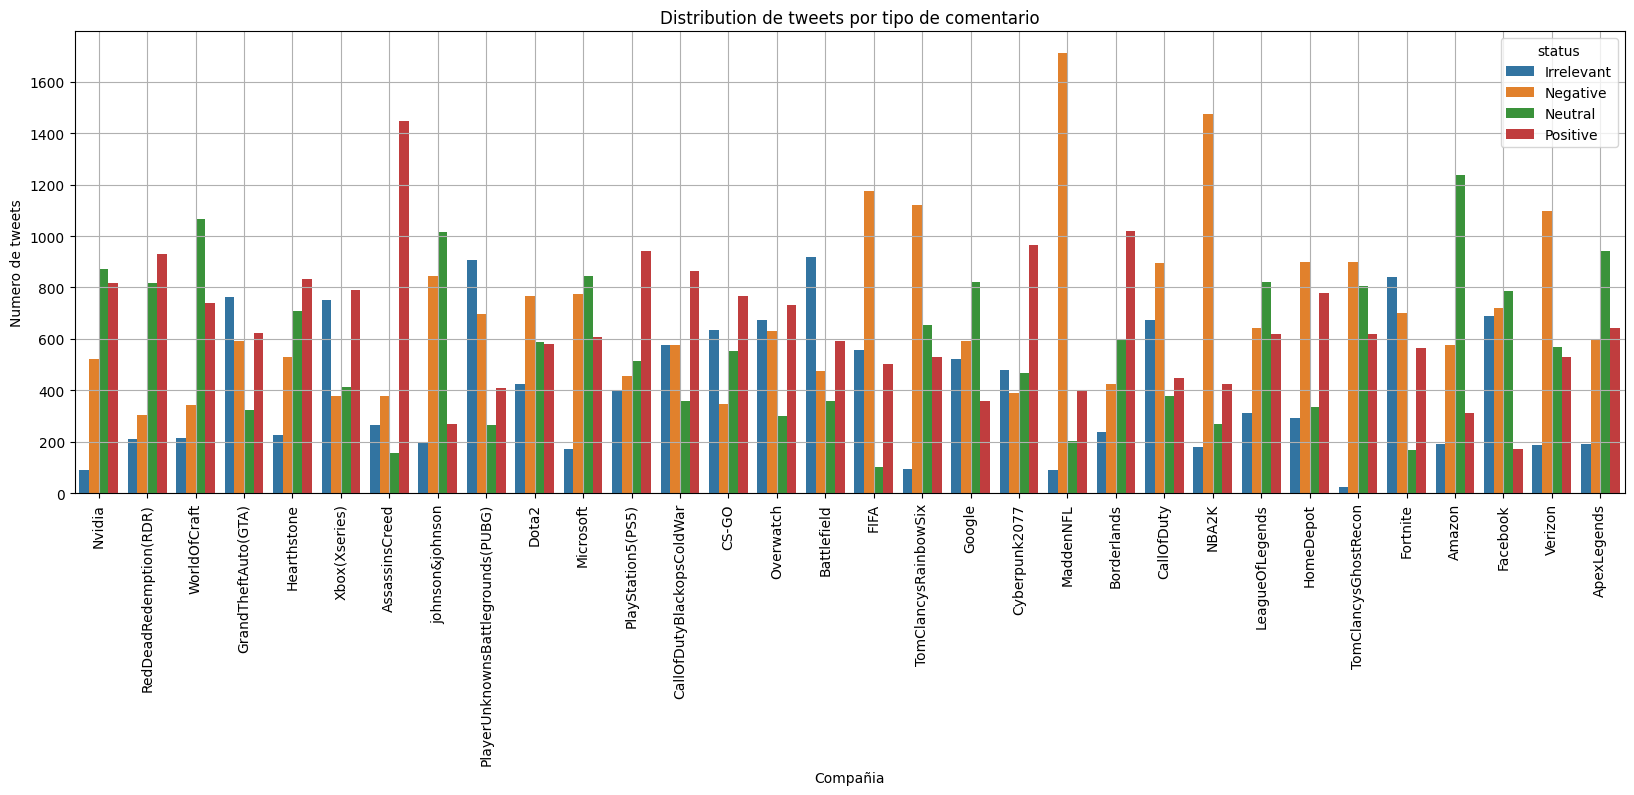

In [27]:
# Crear la figura y la gráfica con seaborn
plt.figure(figsize=(20, 6))
sns.barplot(data=plot1_df, x="information", y="count", hue="status") # Changed y to 'count'
plt.xticks(rotation=90)
plt.xlabel("Compañia")
plt.ylabel("Numero de tweets")
plt.grid(True)
plt.title("Distribution de tweets por tipo de comentario")
plt.show()

In [28]:
# Contar las ocurrencias de cada valor en la columna "status"
status_counts = df_twitter.group_by("status").agg(pl.len().alias("count"))

<ipython-input-29-8103b344f575>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='status', y='count', data=status_counts_df, palette='viridis')


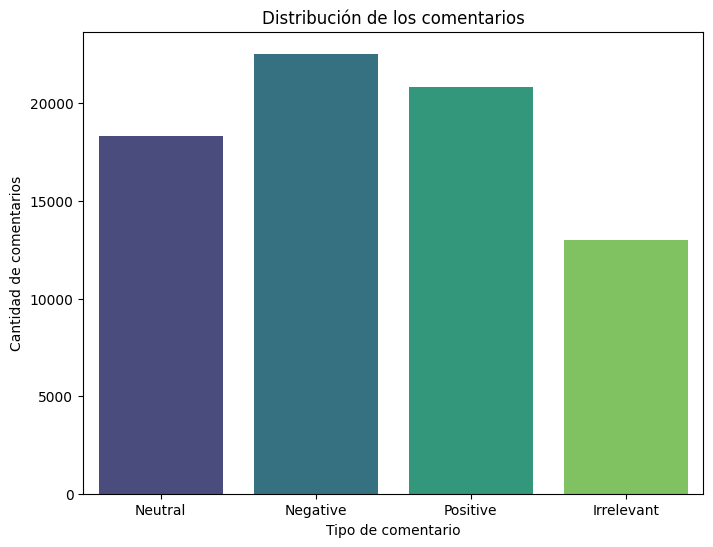

In [29]:
# Convertir el DataFrame de Polars a pandas
status_counts_df = status_counts.to_pandas()

# Crear la gráfica con seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='status', y='count', data=status_counts_df, palette='viridis')
plt.title("Distribución de los comentarios")
plt.xlabel("Tipo de comentario")
plt.ylabel("Cantidad de comentarios")
plt.show()

#Contar status



In [30]:
df_status_counts = (
    df_twitter.group_by("status")
    .agg(pl.len().alias("count"))  # Contar ocurrencias
    .sort("count", descending=True)  # Ordenar de mayor a menor
)
print(df_status_counts)

shape: (4, 2)
┌────────────┬───────┐
│ status     ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ Negative   ┆ 22542 │
│ Positive   ┆ 20831 │
│ Neutral    ┆ 18318 │
│ Irrelevant ┆ 12990 │
└────────────┴───────┘


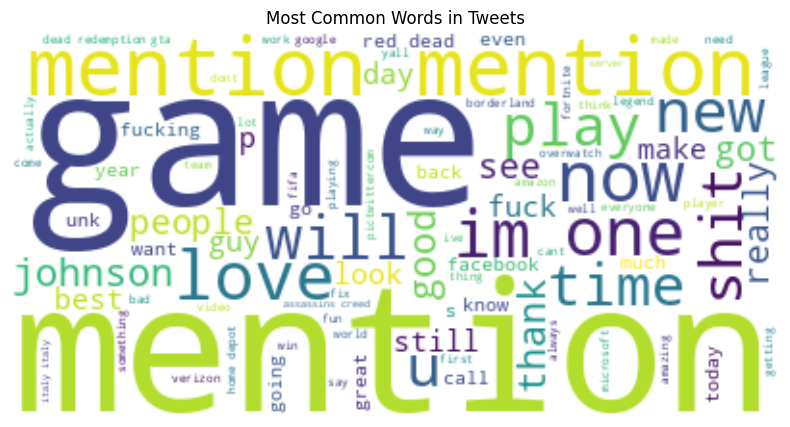

In [31]:
from wordcloud import WordCloud
# Concatenar todos los comentarios en un solo texto
# Convert the series to a list of strings, filtering out None values
text = " ".join([str(comment) for comment in df_twitter.select("comment").to_series() if comment is not None])
# Crear la nube de palabras
wordcloud = WordCloud(background_color="white").generate(text)
# Visualizar la nube de palabras
plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Most Common Words in Tweets")
plt.axis("off")
plt.show()

#Nube palabras positivas

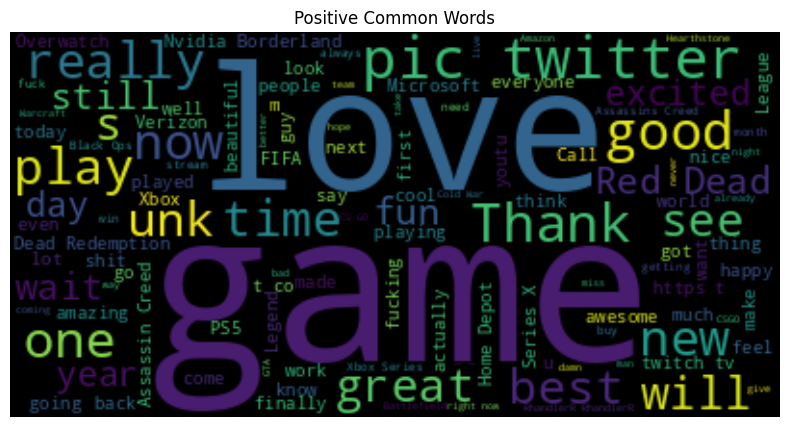

In [32]:
# Filtro de comentarios positivos
positive_comments = df_twitter_2.filter(pl.col("status") == "Positive").select("comment").to_series()

# Concatenar los comentarios positivos en un solo texto
text_positive = " ".join([str(comment) for comment in positive_comments if comment is not None])

# Generar la nube de palabras para comentarios positivos
wordcloud_positive = WordCloud(background_color="black").generate(text_positive)

# Visualizar la nube de palabras para comentarios positivos
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.title("Positive Common Words")
plt.axis("off")
plt.show()

#Nube palabras negativas

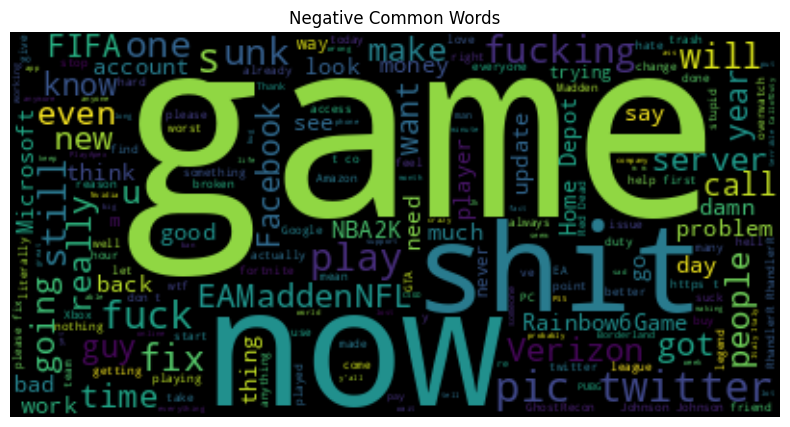

In [33]:
# Filtro de comentarios negativos
negative_comments = df_twitter_2.filter(pl.col("status") == "Negative").select("comment").to_series()

# Concatenar los comentarios negativos en un solo texto
text_negative = " ".join([str(comment) for comment in negative_comments if comment is not None])

# Generar la nube de palabras para comentarios negativos
wordcloud_negative = WordCloud(background_color="black").generate(text_negative)

# Visualizar la nube de palabras para comentarios negativos
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.title("Negative Common Words")
plt.axis("off")
plt.show()

#Histograma de la frecuencia de palabras

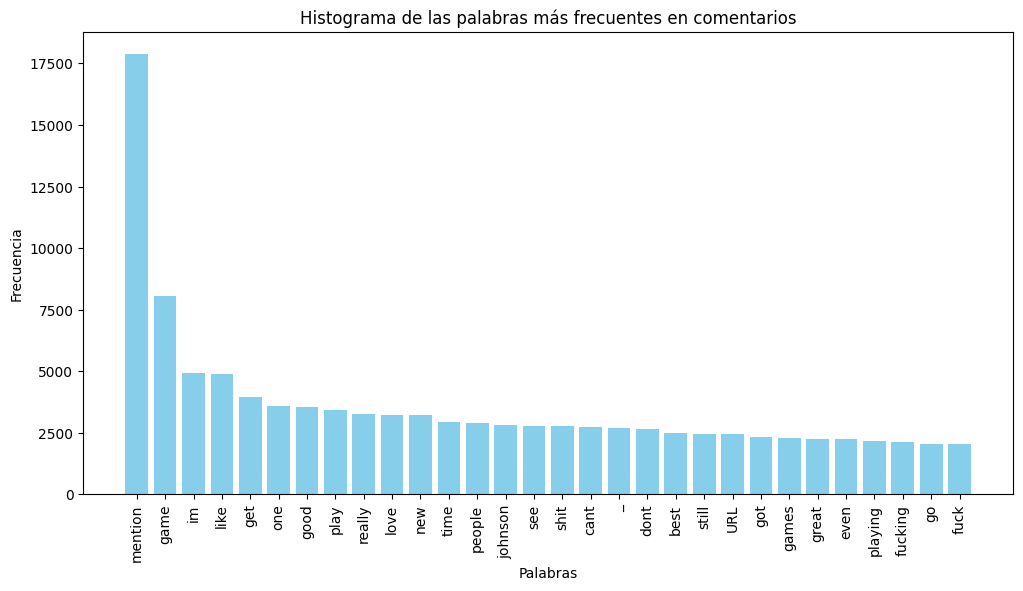

In [37]:
# Seleccionar las palabras más comunes (ejemplo: top 30)
top_words = df_words.head(30)

plt.figure(figsize=(12, 6))
plt.bar(top_words["words"], top_words["count"], color="skyblue")
plt.xticks(rotation=90)
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.title("Histograma de las palabras más frecuentes en comentarios")
plt.show()

#Histograma de la cantidad de palabras por comentario

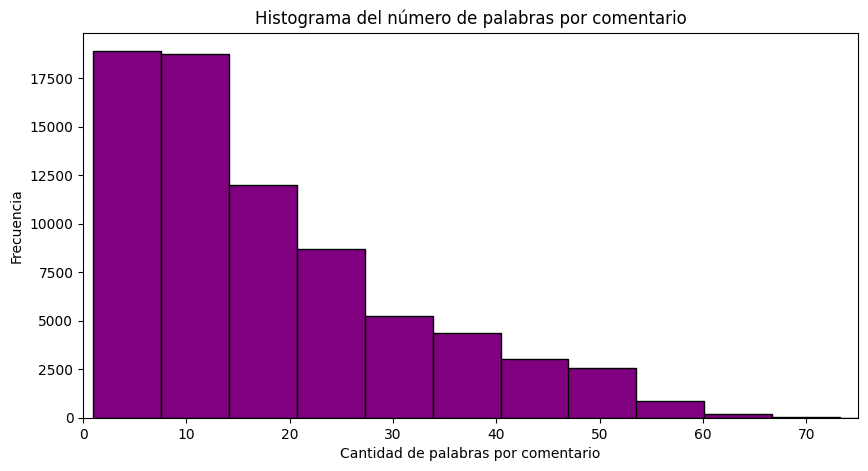

In [39]:
df_twitter = df_twitter.with_columns(
    pl.col("comment").str.split(" ").list.len().alias("word_count")
)

plt.figure(figsize=(10, 5))
plt.hist(df_twitter["word_count"], bins=30, color="purple", edgecolor="black")
plt.xlabel("Cantidad de palabras por comentario")
plt.ylabel("Frecuencia")
plt.title("Histograma del número de palabras por comentario")
plt.xlim(0, 75)  # Limito el eje x hasta 75
plt.show()

#Histograma de la distribución de sentimientos

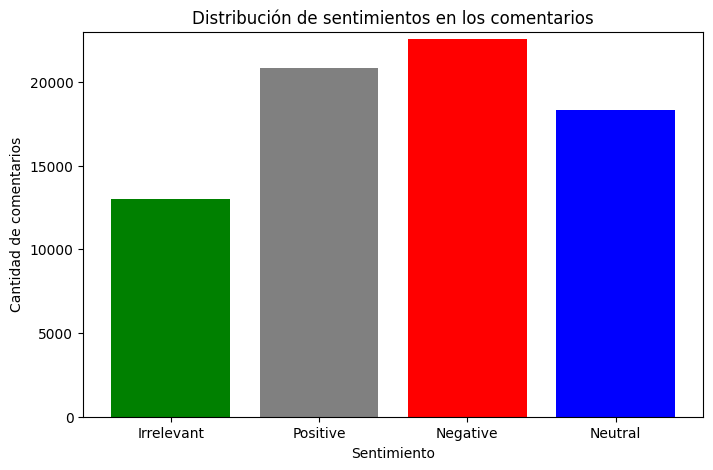

In [44]:
# Contar frecuencia de cada status
df_status_counts = (
    df_twitter.group_by("status")
    .agg(pl.len().alias("count"))
)

plt.figure(figsize=(8, 5))
plt.bar(df_status_counts["status"], df_status_counts["count"], color=["green", "gray", "red", "blue"])
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de comentarios")
plt.title("Distribución de sentimientos en los comentarios")
plt.ylim(0, 23000)  # Limitar el eje y para mejor visualización
plt.show()